In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [188]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [190]:
df.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [191]:
df["Extracurricular Activities encoded"] = df["Extracurricular Activities"].map({"Yes":1, 
                                                                                 "No": 0})
df["Extracurricular Activities encoded"]

0       1
1       0
2       1
3       1
4       0
       ..
9995    1
9996    1
9997    1
9998    1
9999    0
Name: Extracurricular Activities encoded, Length: 10000, dtype: int64

In [192]:
df.duplicated().sum()

np.int64(127)

In [193]:
df.drop_duplicates(inplace= True)

In [194]:
df.duplicated().sum()

np.int64(0)

In [195]:
df.drop(columns=["Extracurricular Activities"], inplace=True)
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities encoded
0,7,99,9,1,91.0,1
1,4,82,4,2,65.0,0
2,8,51,7,2,45.0,1
3,5,52,5,2,36.0,1
4,7,75,8,5,66.0,0


In [196]:
target = np.array(df["Performance Index"])
target

array([91., 65., 45., ..., 74., 95., 64.], shape=(9873,))

In [197]:
X = np.array(df.drop(columns=["Performance Index"]))
print(X)
print(X.shape)

[[ 7 99  9  1  1]
 [ 4 82  4  2  0]
 [ 8 51  7  2  1]
 ...
 [ 6 83  8  5  1]
 [ 9 97  7  0  1]
 [ 7 74  8  1  0]]
(9873, 5)


In [198]:
weights = np.zeros(X.shape[1] + 1)
weights.shape

(6,)

In [199]:
bias = np.ones((X.shape[0], 1))
bias.shape

(9873, 1)

In [200]:
X = np.hstack((bias, X))
print(X)
print(X.shape)

[[ 1.  7. 99.  9.  1.  1.]
 [ 1.  4. 82.  4.  2.  0.]
 [ 1.  8. 51.  7.  2.  1.]
 ...
 [ 1.  6. 83.  8.  5.  1.]
 [ 1.  9. 97.  7.  0.  1.]
 [ 1.  7. 74.  8.  1.  0.]]
(9873, 6)


In [201]:
h_of_x = X @ weights
print(h_of_x)

[0. 0. 0. ... 0. 0. 0.]


In [202]:
deltas = h_of_x - target
print(deltas)

[-91. -65. -45. ... -74. -95. -64.]


In [203]:
learning_rate = 0.00000001
for i in range(0, 10000):
    h_of_x = X @ weights
    deltas = h_of_x - target
    for index in range(0, weights.shape[0]):
        gradient = deltas * X[:, index]
        weights[index] = weights[index] - learning_rate * gradient.sum()

In [204]:
predictions = X @ weights
print(predictions)

[81.94187636 68.67399843 47.45896831 ... 67.02772533 87.84641868
 63.18218609]


In [205]:
error = predictions - target
mse = (error ** 2).mean()
print(mse)

32.706050239990496


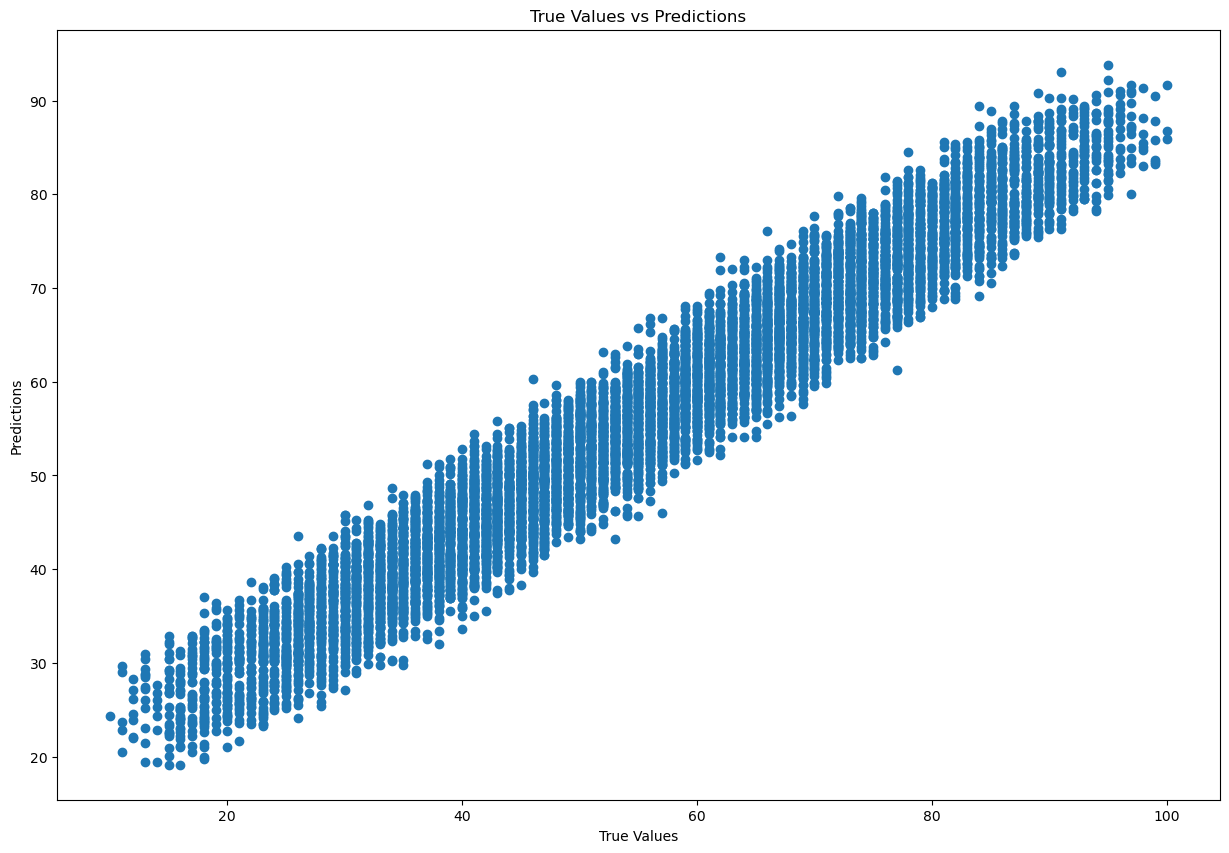

In [206]:
plt.figure(figsize=(15, 10))
plt.scatter(target, predictions)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True Values vs Predictions")
plt.show()